# Removendo Ruído de um Sinal de Sensor de Processo com PROC LOESS

## Resumo Executivo

Um sensor de temperatura da câmara de uma fornalha em uma linha de fabricação é amostrado uma vez por segundo durante a partida, então cada leitura mistura uma transição térmica não linear lenta (uma rampa rápida de aquecimento, uma ultrapassagem de acomodação e depois um retorno ao ponto de ajuste de 300 °C) com ruído de medição substancial. Este notebook usa o **PROC LOESS** para recuperar o sinal subjacente de forma não paramétrica. No registro de 100 amostras, o critério AICC selecionou um parâmetro de suavização de 0.08 (8 parâmetros equivalentes); a curva resultante acompanha de perto o sinal latente, deixando resíduos com desvio-padrão de 3.10 °C — essencialmente o ruído de 4 °C que injetamos, menos a variância que o ajuste explica. Em comparação com a verdade conhecida, a estimativa LOESS reduz o erro quadrático médio de 14.77 (bruto) para 6.63, e uma etapa SCORE reamostra o sinal filtrado em uma grade uniforme de monitoramento para o controle estatístico de processo subsequente.

## Fontes de Dados

| Conjunto de Dados | Linhas | Variáveis | Descrição |
|---------|------|-----------|-------------|
| `sensor` | 100 | `t` (segundos decorridos, 0–99), `temp` (temperatura observada da câmara, °C), `truth` (sinal latente sem ruído, apenas para validação) | Registro sintético do sensor da fornalha, uma amostra por segundo. O sinal latente é uma rampa rápida de aquecimento em direção a um ponto de ajuste de 300 °C, com uma ultrapassagem amortecida que atinge o pico perto de t = 28 (~295 °C), cai, e se acomoda de volta ao ponto de ajuste; a `temp` observada adiciona ruído de medição gaussiano (dp ~4 °C). |
| `grid` | 60 | `t` (grade uniforme de monitoramento 0–99) | Grade de tempo regular usada pela instrução SCORE para emitir um sinal filtrado igualmente espaçado para gráficos de CEP (controle estatístico de processo). |

Em uma linha de fabricação, um sensor da câmara de uma fornalha registra a temperatura uma vez por segundo durante a partida. A leitura que registramos é o **estado térmico real mais ruído de medição**. O estado real não segue nenhuma fórmula paramétrica limpa — ele sobe durante o aquecimento, ultrapassa o ponto de ajuste e depois se acomoda — então um ajuste linear ou polinomial global seria um modelo pobre.

A **regressão local (LOESS)** é a ferramenta certa: ela ajusta polinômios de baixo grau a vizinhanças locais deslizantes, recuperando um sinal suave arbitrário sem que precisemos especificar sua forma funcional. Aqui nós vamos:

1. Simular um registro de sensor realista e ruidoso com 100 amostras.
2. Deixar o `PROC LOESS` escolher sua própria largura de banda de suavização com o critério AICC.
3. Anexar uma banda de confiança de 95% ao sinal ajustado.
4. Pontuar o modelo em uma grade regular para o CEP subsequente.
5. Quantificar o quanto de ruído removemos.

## Etapa 1 — Simular o registro do sensor

Geramos 100 amostras ao longo de 0–99 segundos. O sinal latente `truth` é uma rampa rápida de aquecimento em direção a um ponto de ajuste de 300 °C com uma ultrapassagem amortecida — uma forma que nenhuma reta ou polinômio único capta bem: ele sobe abruptamente, atinge o pico acima do ponto de ajuste perto de t = 28, cai, e depois se acomoda de volta. A `temp` observada adiciona ruído de medição gaussiano. `call streaminit` fixa a semente para que a execução seja reproduzível.

In [1]:
DADOS sensor;
    CHAMAR streaminit(70421);
    setpoint = 300;
    FAZER t = 0 ATÉ 99;
        /* Sinal latente: rampa rápida de aquecimento + ultrapassagem amortecida */
        ramp      = setpoint * (1 - exp(-t / 10));
        overshoot = 40 * exp(-t / 35) * sin(t / 11);
        truth     = ramp + overshoot;
        /* Leitura observada = sinal verdadeiro + ruído de medição (dp ~4 C) */
        temp = truth + rand('NORMAL', 0, 4);
        SAÍDA;
    FIM;
    MANTER t temp truth;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=sensor(obs=8) noobs;
    TÍTULO "Primeiras 8 amostras do sensor";
EXECUTAR;

                                             Primeiras 8 amostras do sensor                                             

t            temp           truth
0    0.1684867131               0
1   28.1933107495   32.0778466448
2   61.6123615699   61.2117857105
3   85.5053781561    87.643846097
4  110.5560474248  111.5945193774
5  136.6368358359  133.2650493509
6  144.2434193147  152.8394750856
7  177.8286488692  170.4864506364

... 92 more observations (showing 8 of 100)




NOTE: DATA sensor


NOTE: Wrote sensor (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=sensor

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## Etapa 2 — Inspecionar o sinal bruto

Um gráfico de dispersão rápido mostra o problema: a deriva subjacente é óbvia a olho nu, mas está soterrada sob ruído de amostra para amostra. Precisamos de uma estimativa da curva suave, não dos pontos irregulares.

                                             Primeiras 8 amostras do sensor                                             




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=sensor

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


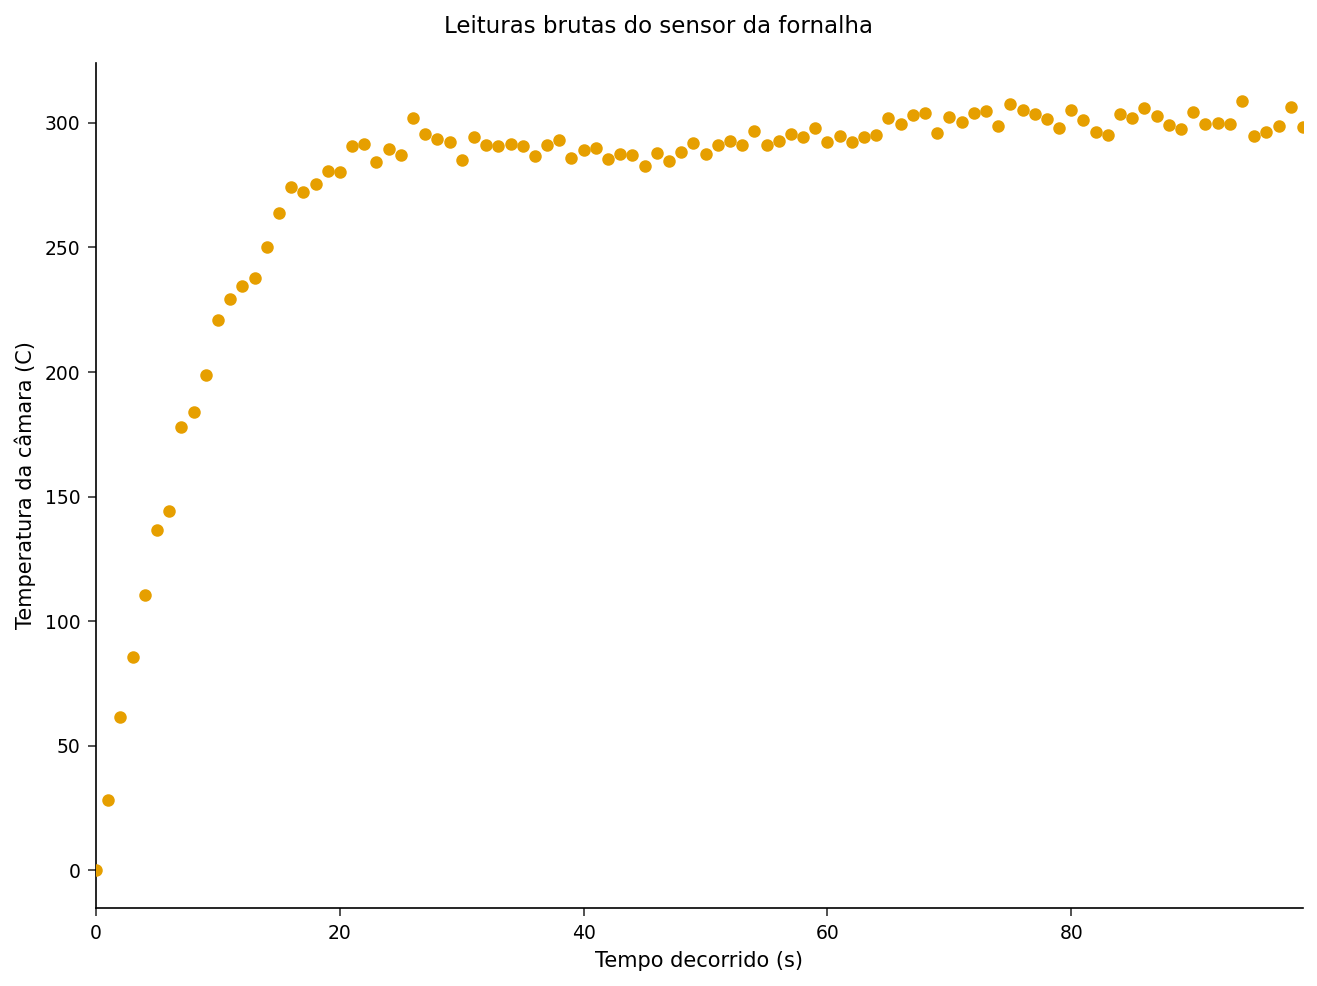

In [2]:
ODS GRAPHICS ON;

PROCEDIMENTO SGPLOT DADOS=sensor;
    scatter x=t y=temp / markerattrs=(symbol=circlefilled size=5);
    xaxis label="Tempo decorrido (s)";
    yaxis label="Temperatura da câmara (C)";
    TÍTULO "Leituras brutas do sensor da fornalha";
EXECUTAR;

ODS GRAPHICS OFF;

## Etapa 3 — Ajustar o LOESS com seleção automática de banda

O parâmetro de suavização controla a largura de cada vizinhança local: pequeno demais sobreajusta o ruído, grande demais apaga a ultrapassagem. Em vez de adivinhar, deixamos o LOESS escolhê-lo minimizando o **Critério de Informação de Akaike corrigido** com `select=AICC`. Usamos polinômios quadráticos locais (`degree=2`) para que a curva possa seguir a curvatura do aquecimento e da ultrapassagem, e solicitamos uma banda de confiança de 95% com `clm` e `alpha=0.05`.

O `ODS OUTPUT` captura duas tabelas como conjuntos de dados: `OutputStatistics` (valores suavizados e resíduos por ponto) e `FitSummary` (a banda selecionada e os diagnósticos de ajuste). A instrução `OUTPUT` grava um conjunto de dados `fitted` com a predição, o resíduo e os limites de confiança de 95% para cada observação — a matéria-prima para os gráficos que se seguem.

In [3]:
PROCEDIMENTO loess DADOS=sensor;
    ODS OUTPUT OutputStatistics=loess_fit
               FitSummary=fit_summary;
    MODELO temp = t / degree=2 select=AICC clm alpha=0.05 details;
    SAÍDA out=fitted predicted=temp_hat residual=resid
          lclm=lower uclm=upper;
EXECUTAR;

                                             Primeiras 8 amostras do sensor                                             


                                                  The LOESS Procedure

Dependent Variable: temp
Number of Observations: 100
Smoothing Parameter: 0.0800
Degree of Local Polynomials: 2

Fit Summary
-----------
Residual Sum of Squares: 950.859192
Equivalent Number of Parameters: 8.00
AICC: 529.0073
GCV: 11.234159

Output Statistics
Obs        Smoothed     Residual       Fitted
---        --------     --------       ------
1           -0.3394       0.5079      -0.3394
2           30.1685      -1.9751      30.1685
3           58.9327       2.6796      58.9327
4           86.1852      -0.6798      86.1852
5          111.5155      -0.9595     111.5155
6          135.0464       1.5904     135.0464
7          155.9315     -11.6881     155.9315
8          168.9956       8.8330     168.9956
9          184.5066      -0.4446     184.5066
10         202.2409      -3.5166     202


NOTE: PROC LOESS data=sensor

NOTE: ODS OUTPUT: OutputStatistics -> loess_fit
NOTE: ODS OUTPUT: FitSummary -> fit_summary
NOTE: Using Python wrapper for LOESS estimation
NOTE: Output dataset fitted has 100 observations
NOTE: ODS OUTPUT: OutputStatistics written to 'loess_fit'.
NOTE: ODS OUTPUT: FitSummary written to 'fit_summary'.


## Etapa 4 — Revisar o modelo selecionado

O Fit Summary (resumo do ajuste) registra o parâmetro de suavização ótimo pelo AICC e o traço da matriz de predição (os graus de liberdade efetivos — uma medida da complexidade do modelo). Um parâmetro de suavização menor e um DF maior significam um ajuste mais ondulado; o AICC equilibra ajuste e complexidade automaticamente.

In [4]:
PROCEDIMENTO IMPRIMIR DADOS=fit_summary noobs label;
    TÍTULO "Resumo do ajuste LOESS (banda selecionada por AICC)";
EXECUTAR;

                                  Resumo do ajuste LOESS (banda selecionada por AICC)                                   

SMOOTHINGPARAMETER                           LABEL1         NVALUE1
              0.08  Residual Sum of Squares          950.8591917253
              0.08  Equivalent Number of Parameters               8
              0.08  Delta1                                        8
              0.08  Delta2                                      7.6
              0.08  Lookup Degrees of Freedom                    92




NOTE: PROC PRINT data=fit_summary

NOTE: PROC PRINT completed: 5 observations printed, 3 variables


## Etapa 5 — Sobrepor o ajuste e a banda de confiança à verdade conhecida

Como estes são dados simulados, mantivemos a coluna `truth`, livre de ruído. Plotar a estimativa LOESS e sua banda de 95% junto com `truth` mostra o quão fielmente o suavizador recuperou o sinal latente que nunca viu diretamente.

                                  Resumo do ajuste LOESS (banda selecionada por AICC)                                   




NOTE: PROC SORT data=fitted

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from fitted.
NOTE: Wrote fitted (100 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=fitted

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: ODS Graphics is OFF.


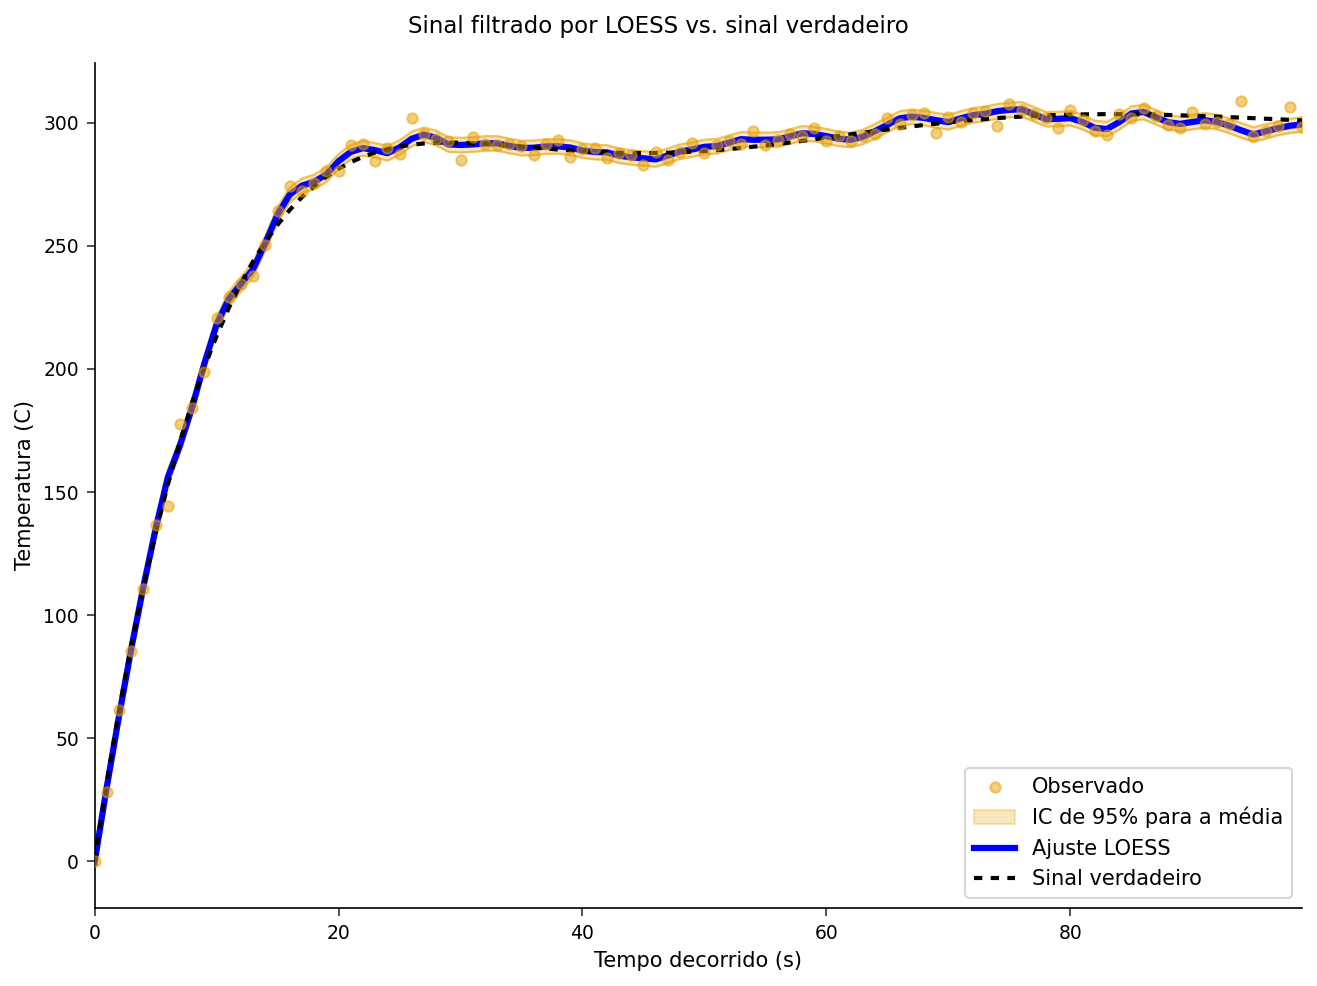

In [5]:
PROCEDIMENTO ORDENAR DADOS=fitted; POR t; EXECUTAR;

ODS GRAPHICS ON;

PROCEDIMENTO SGPLOT DADOS=fitted;
    scatter x=t y=temp / markerattrs=(symbol=circlefilled size=5)
            transparency=0.5 legendlabel="Observado";
    band x=t lower=lower upper=upper / transparency=0.5
         legendlabel="IC de 95% para a média";
    series x=t y=temp_hat / lineattrs=(thickness=3 color=blue)
           legendlabel="Ajuste LOESS";
    series x=t y=truth / lineattrs=(thickness=2 pattern=shortdash color=black)
           legendlabel="Sinal verdadeiro";
    xaxis label="Tempo decorrido (s)";
    yaxis label="Temperatura (C)";
    TÍTULO "Sinal filtrado por LOESS vs. sinal verdadeiro";
EXECUTAR;

ODS GRAPHICS OFF;

## Etapa 6 — Diagnóstico dos resíduos

Os resíduos (observado menos ajustado) devem parecer ruído sem estrutura, centrado em zero. Qualquer tendência remanescente indicaria suavização insuficiente ou uma característica não capturada. Plotamos os resíduos em função do tempo e resumimos sua dispersão — o desvio-padrão dos resíduos sai em 3.10 °C, um pouco abaixo do ruído de 4 °C que injetamos, porque o ajuste local absorve uma pequena parte dele.

                                  Resumo do ajuste LOESS (banda selecionada por AICC)                                   

                                   Resumo dos resíduos (ruído de medição recuperado)                                    

                                                  The MEANS Procedure

 Variable  Label                N        Mean     Std Dev     Minimum     Maximum
 --------------------------------------------------------------------------------
 RESID     Resíduo (C)        100       0.139       3.096     -11.688      11.909
 --------------------------------------------------------------------------------




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=fitted

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg
NOTE: ODS Graphics is OFF.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


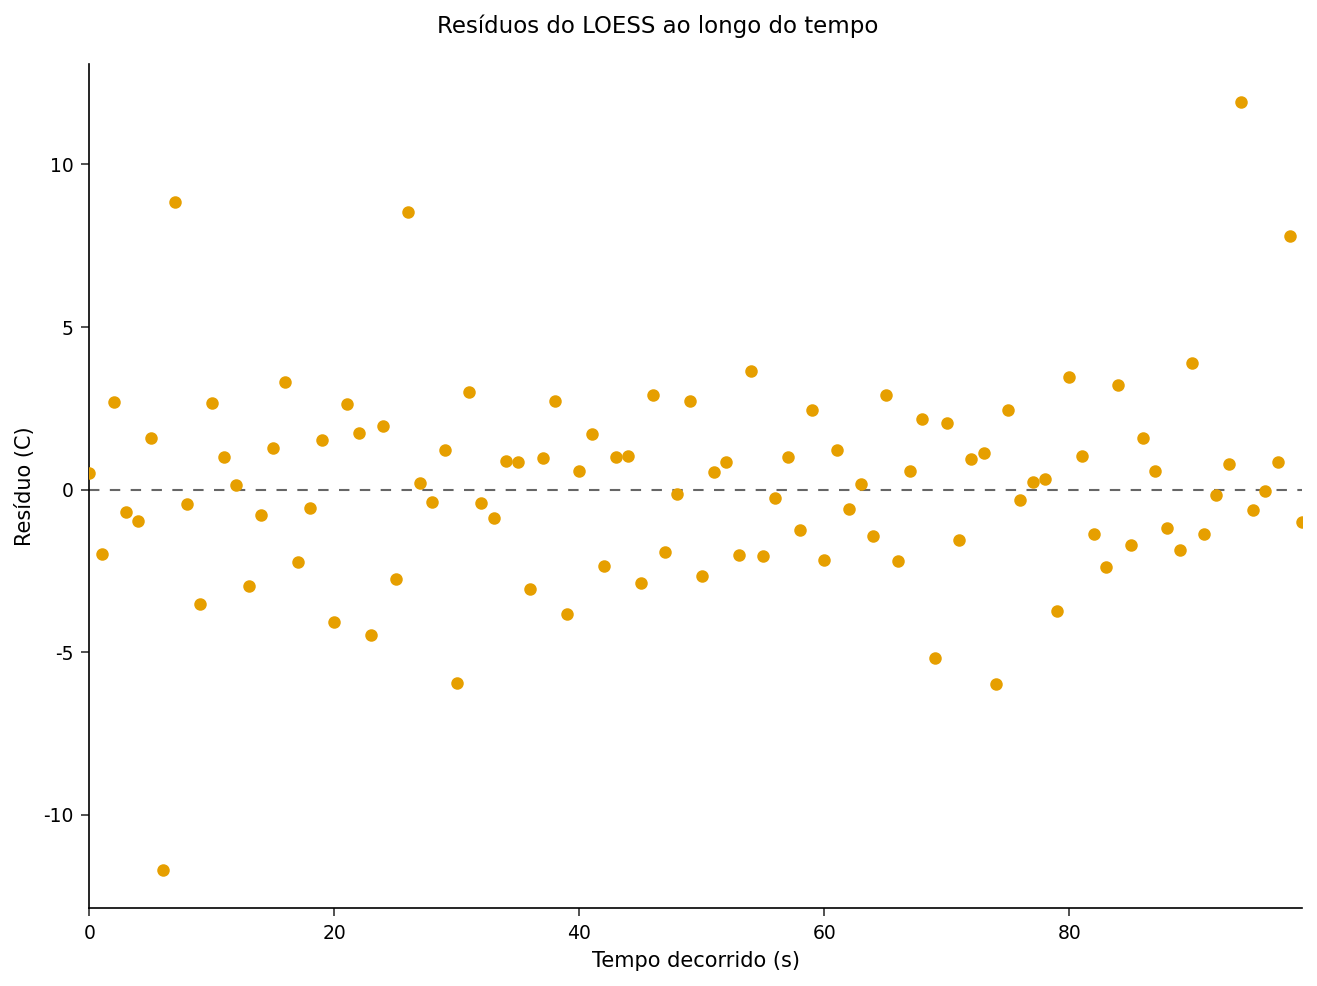

In [6]:
ODS GRAPHICS ON;

PROCEDIMENTO SGPLOT DADOS=fitted;
    refline 0 / axis=y lineattrs=(pattern=shortdash);
    scatter x=t y=resid / markerattrs=(symbol=circlefilled size=5);
    xaxis label="Tempo decorrido (s)";
    yaxis label="Resíduo (C)";
    TÍTULO "Resíduos do LOESS ao longo do tempo";
EXECUTAR;

ODS GRAPHICS OFF;

PROCEDIMENTO MÉDIAS DADOS=fitted n mean std min max maxdec=3;
    VARIÁVEL resid;
    RÓTULO resid="Resíduo (C)";
    TÍTULO "Resumo dos resíduos (ruído de medição recuperado)";
EXECUTAR;

## Etapa 7 — Pontuar uma grade de monitoramento regular para o CEP

Os registros de tempo do sensor não precisam ser igualmente espaçados, mas um gráfico de controle quer o sinal em uma cadência fixa. Construímos uma grade de tempo uniforme de 60 pontos e aplicamos a ela o modelo LOESS ajustado com a instrução `SCORE`, solicitando limites de confiança. Os valores pontuados são um sinal limpo e igualmente espaçado, pronto para alimentar uma rotina de CEP.

In [7]:
DADOS grid;
    FAZER t = 0 ATÉ 99 POR 99/59;
        SAÍDA;
    FIM;
EXECUTAR;

PROCEDIMENTO loess DADOS=sensor;
    MODELO temp = t / degree=2 select=AICC clm alpha=0.05;
    score data=grid clm print;
    TÍTULO "LOESS aplicado a uma grade uniforme de monitoramento";
EXECUTAR;

                                   Resumo dos resíduos (ruído de medição recuperado)                                    


                                                  The LOESS Procedure

Dependent Variable: temp
Number of Observations: 100
Smoothing Parameter: 0.0800
Degree of Local Polynomials: 2

Fit Summary
-----------
Residual Sum of Squares: 950.859192
Equivalent Number of Parameters: 8.00
AICC: 529.0073
GCV: 11.234159

Output Statistics
Obs        Smoothed     Residual       Fitted
---        --------     --------       ------
1           -0.3394       0.5079      -0.3394
2           30.1685      -1.9751      30.1685
3           58.9327       2.6796      58.9327
4           86.1852      -0.6798      86.1852
5          111.5155      -0.9595     111.5155
6          135.0464       1.5904     135.0464
7          155.9315     -11.6881     155.9315
8          168.9956       8.8330     168.9956
9          184.5066      -0.4446     184.5066
10         202.2409      -3.5166     202


NOTE: DATA grid


NOTE: Wrote grid (60 rows, 1 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC LOESS data=sensor

NOTE: Using Python wrapper for LOESS estimation
NOTE: ODS OUTPUT: OutputStatistics written to 'loess_fit'.
NOTE: ODS OUTPUT: FitSummary written to 'fit_summary'.


## Etapa 8 — Quantificar a remoção de ruído

Por fim, comparamos o sinal bruto e a estimativa LOESS com a verdade conhecida. O erro quadrático médio do sinal suavizado deve ser bem menor do que o das leituras brutas, confirmando que o LOESS removeu o ruído de medição preservando a rampa de aquecimento e a ultrapassagem.

In [8]:
DADOS accuracy;
    DEFINIR fitted;
    raw_sq_err   = (temp     - truth)**2;
    loess_sq_err = (temp_hat - truth)**2;
EXECUTAR;

PROCEDIMENTO MÉDIAS DADOS=accuracy mean maxdec=3;
    VARIÁVEL raw_sq_err loess_sq_err;
    RÓTULO raw_sq_err="EQM das leituras brutas vs. verdade"
          loess_sq_err="EQM do ajuste LOESS vs. verdade";
    TÍTULO "Desempenho na remoção de ruído: bruto vs. LOESS";
EXECUTAR;

                                    Desempenho na remoção de ruído: bruto vs. LOESS                                     

                                                  The MEANS Procedure

 Variable      Label                                         Mean
 ----------------------------------------------------------------
 raw_sq_err    EQM das leituras brutas vs. verdade         14.774
 loess_sq_err  EQM do ajuste LOESS vs. verdade              6.629
 ----------------------------------------------------------------




NOTE: DATA accuracy


NOTE: Read 100 rows from fitted.
NOTE: Wrote accuracy (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Interpretando os resultados

- **Banda automática.** `select=AICC` escolheu um parâmetro de suavização de **0.08** sem ajuste manual, implicando cerca de **8 parâmetros equivalentes** — flexibilidade local suficiente para acompanhar o aquecimento, a ultrapassagem e a queda, ao mesmo tempo suavizando o ruído.
- **Recuperação fiel.** A curva ajustada acompanha de perto o sinal latente `truth` ao longo da rampa, do pico de ultrapassagem perto de t = 28, e da cauda de acomodação, demonstrando que o LOESS recuperou um sinal não linear arbitrário sem suposições paramétricas.
- **Resíduos limpos.** Os resíduos se espalham em torno de zero com desvio-padrão de **3.10 °C** (média 0.14, intervalo −11.7 a 11.9) e não mostram tendência temporal remanescente — evidência de que o modelo não está nem super- nem sub-suavizado.
- **Remoção de ruído mensurável.** Em comparação com a verdade conhecida, a estimativa LOESS reduz o erro quadrático médio de **14.77** (leituras brutas) para **6.63** — uma redução de 55%, o principal ganho para o monitoramento de processo.
- **Saída pronta para o CEP.** A etapa SCORE entregou o sinal filtrado em uma grade uniforme de 60 pontos com limites de confiança, exatamente a forma que um gráfico de controle subsequente consome.

**Conclusão:** Quando um sensor de processo produz um sinal suave mas ruidoso de forma desconhecida, o PROC LOESS é uma forma de baixa suposição e auto-ajustável de extrair a tendência subjacente, anexar limites de incerteza e reamostrar em uma grade de monitoramento — tudo sem se comprometer com um modelo paramétrico que a física pode não justificar.